In [3]:
import sys
import os
import pandas as pd


sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.connection import get_db_connection


conn = get_db_connection()

if conn:
    query_tables = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'raw';"
    tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
    
    all_data = {}

    for table in tables:
        all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)
        print(f"Таблица '{table}' загружена! (строк: {len(all_data[table])})")
    
    conn.close()
else:
    print("Ошибка подключения к СУБД")



Успешно: Подключение к СУБД установлено.
Таблица 'gender_submission' загружена! (строк: 418)
Таблица 'test' загружена! (строк: 418)
Таблица 'train' загружена! (строк: 891)


C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_9028\3585626067.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_9028\3585626067.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500              S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250              S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500              S  
<c

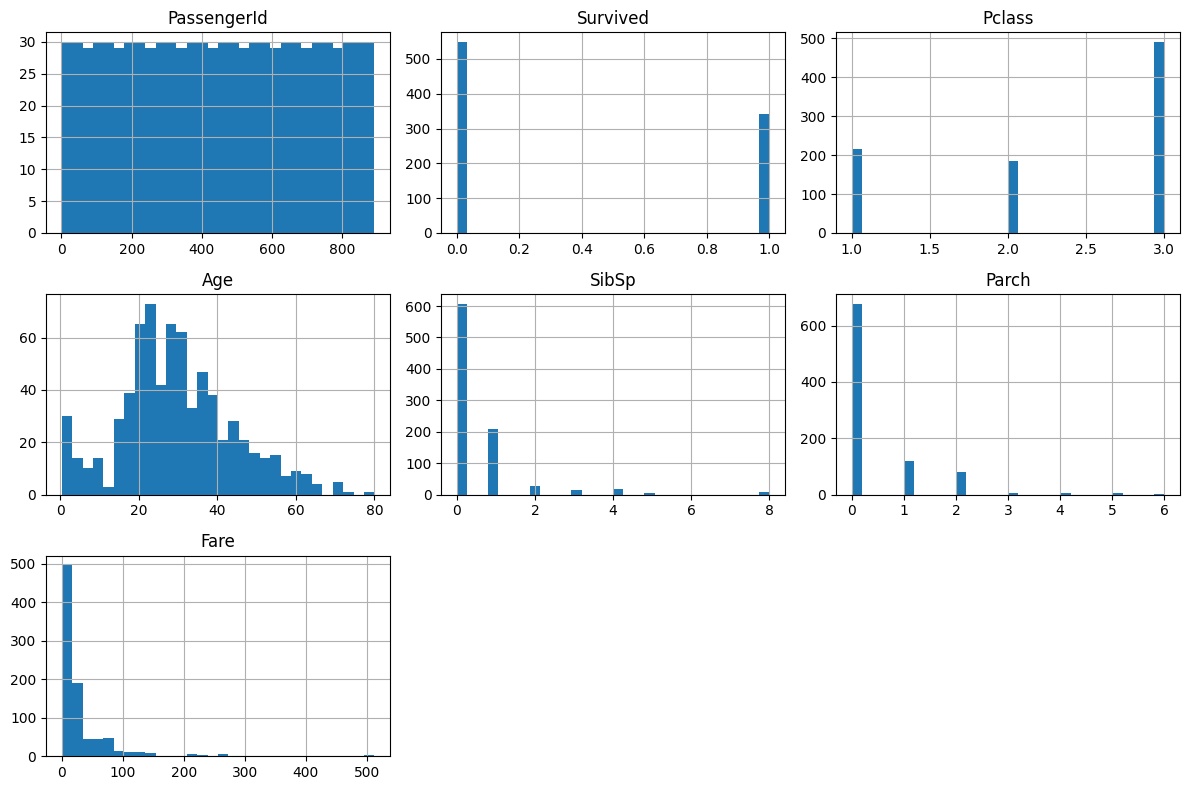

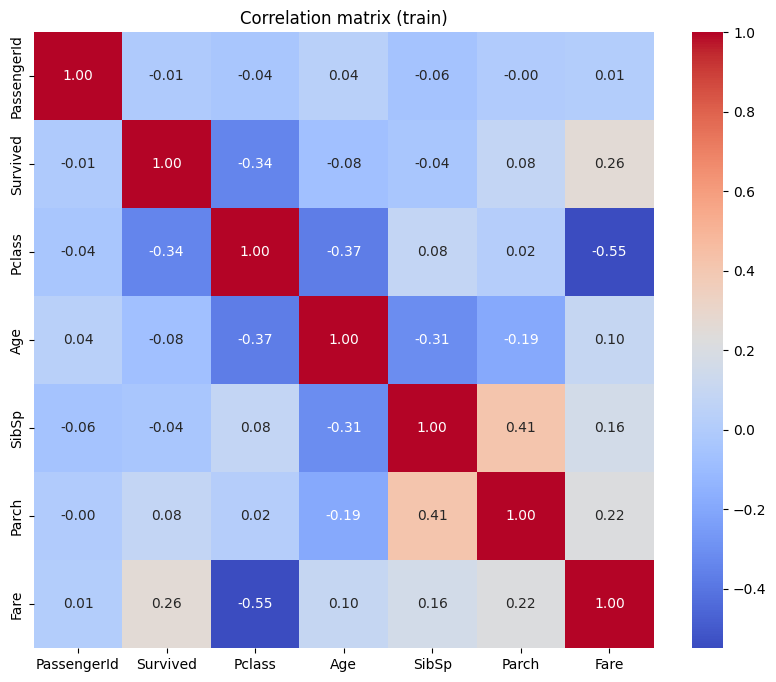

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

train = all_data.get('train')
if train is None:
    raise ValueError("Table 'train' не найдена в all_data")

# базовый обзор
print(train.head())
print(train.info())
print(train.describe(include='all'))

# пример визуализации: распределение числовых колонок
numeric_cols = train.select_dtypes(include='number').columns.tolist()
if numeric_cols:
    train[numeric_cols].hist(figsize=(12, 8), bins=30)
    plt.tight_layout()
    plt.show()

# пример: корреляция
if len(numeric_cols) > 1:
    corr = train[numeric_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation matrix (train)")
    plt.show()

# пример: категория vs целевая (если есть)
# замените 'target' на имя вашей целевой колонки
target_col = 'target'
if target_col in train.columns:
    for cat in train.select_dtypes(include=['object', 'category']).columns:
        plt.figure(figsize=(10, 4))
        sns.countplot(data=train, x=cat, hue=target_col)
        plt.title(f"{cat} vs {target_col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()